In [9]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [10]:
# ##### 1. Read Data #####
df_early = pd.read_csv("data/SPY_15min_2002-01_to_2006-08.csv")
df_late = pd.read_csv("data/SPY_15min_2020-01_to_2022-01.csv")
df_events = pd.read_csv("data/WhatMovesMarkets_eventdatabase.csv")

In [11]:
# ##### 2. Prepare Stock-Data #####
def prepare_price_data(df, label):
    df['datetime'] = pd.to_datetime(df['Unnamed: 0'], utc=True) 
    df = df.sort_values('datetime') # make sure that our df is sorted cronologically
    df.set_index('datetime', inplace=True)
    df['log_return'] = np.log(df['close'] / df['close'].shift(1)) # log returns (time-additive and robust)
    df['period'] = label
    return df

df_early_cleaned = prepare_price_data(df_early, '2002–2006')
df_late_cleaned = prepare_price_data(df_late, '2020–2022')

In [12]:
# ##### 3. Adjust Timezone and clean Data ####


df_events['eventstart'] = pd.to_datetime(
    df_events['eventstart_CET'], dayfirst=True, errors='coerce'
)

# select correct timezone: convert timezone from CET to UTC (event-dataframe)
df_events['eventstart'] = df_events['eventstart'].dt.tz_localize('CET', ambiguous='NaT', nonexistent='NaT')
df_events['eventstart'] = df_events['eventstart'].dt.tz_convert('UTC')

# Drop rows without correct time
df_events = df_events.dropna(subset=['eventstart'])

# Making sure events happen in 15min intervalls
df_events['event_bin'] = df_events['eventstart'].dt.floor('15min')
df_events_reduced = df_events[['event_bin', 'type']].drop_duplicates()
df_events_reduced['dummy'] = 1

# Create dummies for every event-type
df_event_dummies = df_events_reduced.pivot_table(index='event_bin', columns='type', values='dummy', fill_value=0)

df_event_dummies.columns = [f'event_{col.replace(" ", "_")}' for col in df_event_dummies.columns]


In [13]:
# ##### 4. OLS Regression with multiple dummy regressors #####
def merge_and_regress(price_df):
    df = price_df.merge(df_event_dummies, left_index=True, right_index=True, how='left').fillna(0) #Left-join --> all stockprices included
    df = df.dropna(subset=['log_return'])
    X = df[[col for col in df.columns if col.startswith('event_')]] # Design-matrix of the events
    X = sm.add_constant(X)
    y = df['log_return']
    model = sm.OLS(y, X).fit()
    return model, df

model_early, df_early_reg = merge_and_regress(df_early_cleaned)
model_late, df_late_reg = merge_and_regress(df_late_cleaned)

In [14]:
# ##### 5. Variance decomposition Omega_k  #####
def compute_omega_k(model, df):
    X = df[[col for col in df.columns if col.startswith('event_')]]
    betas = model.params[X.columns] # estimated parameters --> measures the event's impact
    total_var = np.var(model.model.endog) 

    omega_k = {}
    for col in X.columns:
        contribution = np.var(X[col] * betas[col]) # measures how much an eventtype impacts the variance
        omega_k[col] = max(contribution / total_var, 0) if total_var != 0 else 0
    return pd.DataFrame.from_dict(omega_k, orient='index', columns=['Omega_k']).sort_values(by='Omega_k', ascending=False)

omega_early = compute_omega_k(model_early, df_early_reg)
omega_late = compute_omega_k(model_late, df_late_reg)

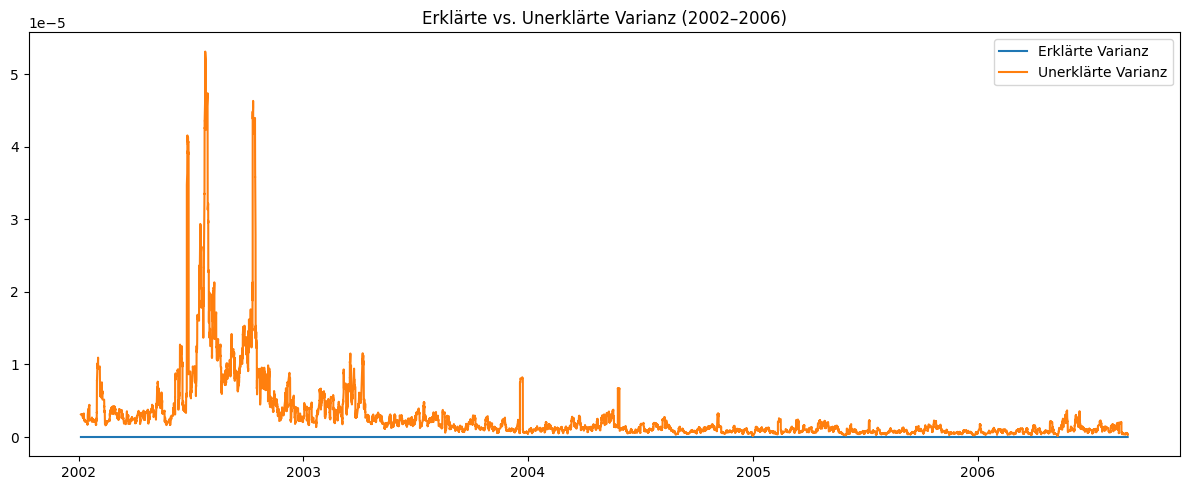

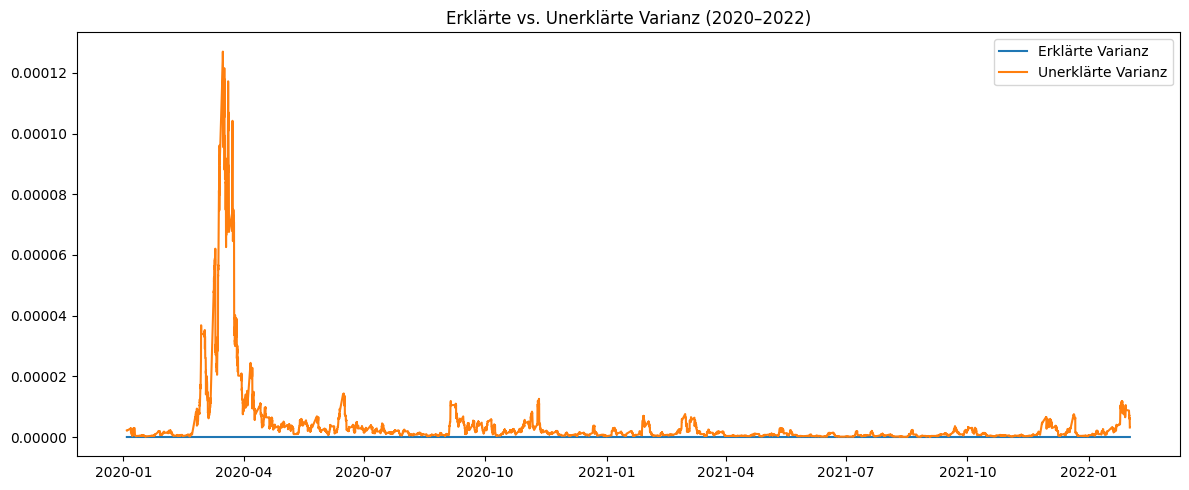

In [15]:
# ##### 6a. Zeitreihe: Erklärte vs. Unerklärte Varianz #####
def plot_explained_variance(df, model, title):
    X = df[[col for col in df.columns if col.startswith('event_')]]
    X = sm.add_constant(X)
    y_hat = model.predict(X)
    residuals = df['log_return'] - y_hat
    explained = y_hat.rolling(96).var()
    unexplained = residuals.rolling(96).var()

    plt.figure(figsize=(12, 5))
    plt.plot(explained, label='Erklärte Varianz')
    plt.plot(unexplained, label='Unerklärte Varianz')
    plt.title(f'Erklärte vs. Unerklärte Varianz ({title})')
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_explained_variance(df_early_reg, model_early, "2002–2006")
plot_explained_variance(df_late_reg, model_late, "2020–2022")

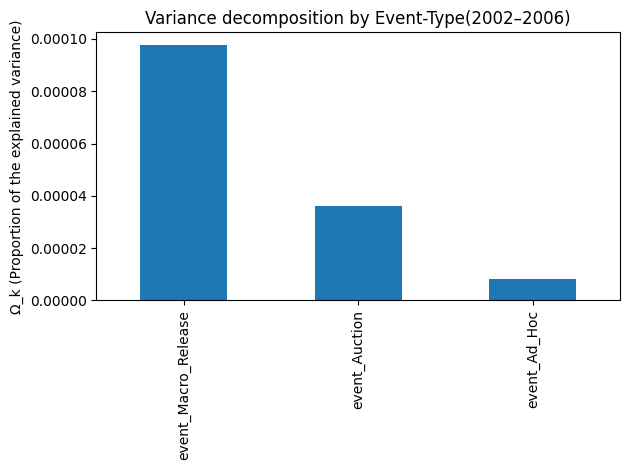

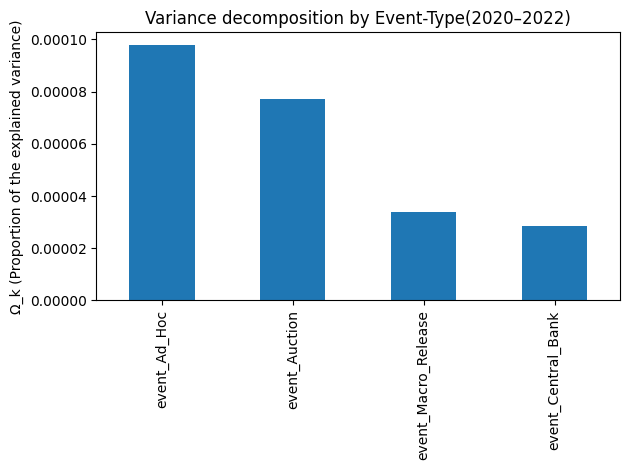

=== Regression 2002–2006 ===
                            OLS Regression Results                            
Dep. Variable:             log_return   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1.803
Date:                Fri, 11 Jul 2025   Prob (F-statistic):              0.125
Time:                        14:13:21   Log-Likelihood:             2.5757e+05
No. Observations:               51289   AIC:                        -5.151e+05
Df Residuals:                   51284   BIC:                        -5.151e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const

In [16]:
# ##### 6b. Omega_k Barplot by eventtype #####
def plot_omega(omega_df, title):
    omega_df_filtered = omega_df[omega_df['Omega_k'] > 0.000001]
    if omega_df_filtered.empty:
        print(f" No significant Omega_k-values for {title} –-> no plot")
        return
    omega_df_filtered.plot(kind='bar', legend=False)
    plt.ylabel("Ω_k (Proportion of the explained variance)")
    plt.title(f"Variance decomposition by Event-Type({title})")
    plt.tight_layout()
    plt.show()

plot_omega(omega_early, "2002–2006")
plot_omega(omega_late, "2020–2022")

# ##### 7. Optional: Show OLS tables #####
print("=== Regression 2002–2006 ===")
print(model_early.summary())
print("\n=== Regression 2020–2022 ===")
print(model_late.summary())


In [17]:
def bootstrap_omega_k(price_df, n_bootstrap=30, block_size=26):
    n = len(price_df)
    omega_bootstrap = []

    for _ in range(n_bootstrap):
        resampled_df = []
        while len(resampled_df) < n:
            start = np.random.randint(0, n - block_size)
            block = price_df.iloc[start:start + block_size]
            resampled_df.append(block)
        resampled_df = pd.concat(resampled_df).iloc[:n]

        X = resampled_df[[col for col in resampled_df.columns if col.startswith('event_')]]
        X = sm.add_constant(X)
        y = resampled_df['log_return']
        model = sm.OLS(y, X).fit()

        betas = model.params[X.columns]
        total_var = np.var(y)
        omega_k = {}
        for col in X.columns:
            if col == 'const':
                continue
            contribution = np.var(X[col] * betas[col])
            omega_k[col] = max(contribution / total_var, 0) if total_var != 0 else 0
        omega_bootstrap.append(omega_k)

    return pd.DataFrame(omega_bootstrap)

# Bootstrap erneut ausführen
omega_boot_early = bootstrap_omega_k(df_early_reg)
omega_boot_late = bootstrap_omega_k(df_late_reg)

In [18]:
omega_boot_early

,event_Ad_Hoc,event_Auction,event_Central_Bank,event_Macro_Release
0,8.710680e-06,0.000059,2.444734e-07,2.678139e-05
1,5.803778e-05,0.000095,5.168330e-06,1.131593e-05
2,5.060078e-05,0.000016,5.592761e-07,1.132304e-05
3,1.319392e-04,0.000047,9.646574e-05,1.258002e-05
4,2.078971e-05,0.000050,7.015360e-06,9.356762e-08
5,2.161181e-05,0.000158,3.011787e-06,4.011109e-05
6,6.006007e-04,0.000018,1.377202e-04,4.721066e-04
7,2.503369e-04,0.000018,1.588171e-04,1.173091e-04
8,9.781569e-05,0.000056,1.939879e-07,2.355266e-04
9,2.227831e-06,0.000050,1.746887e-05,3.360786e-04


In [19]:
# Zusammenfassung berechnen inkl. Konfidenzintervall
def summarize_bootstrap(df_boot):
    mean = df_boot.mean()
    std = df_boot.std()
    ci_lower = mean - 1.96 * std
    ci_upper = mean + 1.96 * std
    return pd.DataFrame({
        "Omega_k_mean": mean,
        "Omega_k_std": std,
        "CI_lower": ci_lower,
        "CI_upper": ci_upper
    }).sort_values(by="Omega_k_mean", ascending=False)

summary_early = summarize_bootstrap(omega_boot_early)
summary_late = summarize_bootstrap(omega_boot_late)

# Optional: anzeigen
print("=== Bootstrap Summary 2002–2006 ===")
print(summary_early)

print("\n=== Bootstrap Summary 2020–2022 ===")
print(summary_late)

=== Bootstrap Summary 2002–2006 ===
                     Omega_k_mean  Omega_k_std  CI_lower  CI_upper
event_Ad_Hoc             0.000174     0.000263 -0.000340  0.000689
event_Macro_Release      0.000143     0.000158 -0.000167  0.000452
event_Auction            0.000054     0.000038 -0.000021  0.000129
event_Central_Bank       0.000025     0.000039 -0.000052  0.000102

=== Bootstrap Summary 2020–2022 ===
                     Omega_k_mean  Omega_k_std  CI_lower  CI_upper
event_Ad_Hoc             0.000443     0.000519 -0.000575  0.001461
event_Central_Bank       0.000129     0.000165 -0.000194  0.000452
event_Auction            0.000105     0.000130 -0.000149  0.000360
event_Macro_Release      0.000078     0.000125 -0.000167  0.000323
